# Neural Network — Solving XOR with Hidden Layers

## Goal
A single perceptron failed on XOR.
Adding a hidden layer solves it — by learning non-linear boundaries.

## Key Questions
- How do hidden layers add non-linearity?
- What is an activation function and why does it matter?
- How does a network with multiple neurons learn?

## What We Build
A 2-layer neural network from scratch using numpy.
No PyTorch — we implement forward pass, loss, and backpropagation manually.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Activation Functions
The key difference from a perceptron — we use sigmoid instead of step function.
Sigmoid is differentiable, which allows backpropagation.

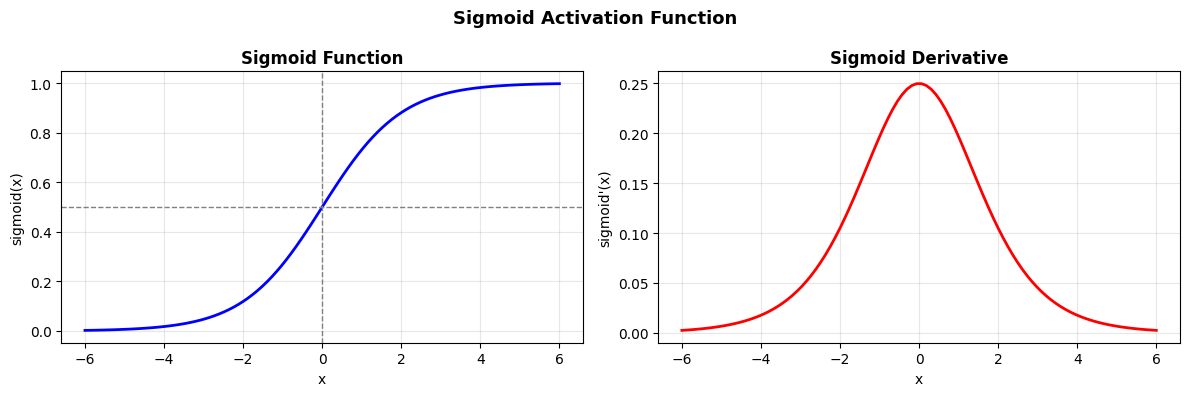

In [2]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """Sigmoid activation — squashes values between 0 and 1."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x: np.ndarray) -> np.ndarray:
    """Derivative of sigmoid — needed for backpropagation."""
    s = sigmoid(x)
    return s * (1 - s)

# Visualize
x = np.linspace(-6, 6, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, sigmoid(x), color="blue", linewidth=2)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes[0].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Sigmoid Function", fontsize=12, fontweight="bold")
axes[0].set_xlabel("x")
axes[0].set_ylabel("sigmoid(x)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, sigmoid_derivative(x), color="red", linewidth=2)
axes[1].set_title("Sigmoid Derivative", fontsize=12, fontweight="bold")
axes[1].set_xlabel("x")
axes[1].set_ylabel("sigmoid'(x)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Sigmoid Activation Function", fontsize=13, fontweight="bold" )
plt.tight_layout()
plt.savefig("sigmoid.png", dpi=300)
plt.show()

## 2. Neural Network Architecture
Two layers: hidden layer (2 neurons) + output layer (1 neuron).
This is the minimum needed to solve XOR.

class NeuralNetwork:
    """
    2-layer neural network built from scratch.
    Architecture: input(2) -> hidden(1) -> output(1)
    """

    def __init__(self, learning_rate: float = 0.1):
        self.lr = learning_rate
        self.losses = []

        # Hidden layer weights and bias
        np.random.seed(42)
        self.W1 = np.random.rand(2, 2)* 0.5
        self.b1 = np.zeros((1, 2))

        # Output layer weights and bias
        self.W2 = np.random.randn(2, 1) * 0.5
        self.b2 = np.zeros((1, 1))

    def forward(self, X: np.ndarray) -> np.ndarray:
        """Forward pass - compute predictions."""
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self, X: np.ndarray, y: np.ndarray) -> None:
        """Backpropagation - update weights based on error."""
        m = X.shape[0]

        # Output layer gradinets
        dL_da2 = self.a2 - y.reshape(-1, 1)
        dL_dz2 = dL_da2 * sigmoid_derivative(self.z2)
        dL_dW2 = np.dot(self.a1.T, dL_dz2) / m
        dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True) / m

        # Hidden layer gradinets
        dL_da1 = np.dot(dL_dz2, self.W2.T)
        dL_dz1 = dL_da1 * sigmoid_derivative(self.z1)
        dL_dW1 = np.dot(X.T, dL_dz1) / m
        dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= self.lr * dL_dW2
        self.b2 -= self.lr * dL_db2
        self.W1 -= self.lr * dL_dW1
        self.b1 -= self.lr * dL_db1

    def train(self, X: np.ndarray, y: np.ndarray, epochs: int = 10000) -> None:
        """Train the network."""
        for epoch in range(epochs):
            output = self.forward(X)
            loss = np.mean((output - y.reshape(-1, 1)) ** 2)
            self.losses.append(loss)
            self.backward(X, y)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Predict binary labels."""
        output = self.forward(X)
        return (output >= threshold).astype(int).flatten()

    def accuracy(self, X: np.ndarray, y: np.ndarray) -> float:
        return np.mean(self.predict(X) == y)


print("NeuralNetwork class defined.")
print("Architecture: input(2) -> hidden(2) -> output(1)")

## 3. Train on XOR

In [10]:
# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

# Train
nn= NeuralNetwork(learning_rate=0.5)
nn.train(X_xor, y_xor, epochs=10000)

# Results
print("XOR Result with Neural Network:")
print(f"{'Input':<15} {'Expected':>10} {'Predict':>10} {'Confidence':>12}")
print("-" * 50)
for xi, yi in zip(X_xor, y_xor):
    pred = nn.predict([xi])[0]
    conf = nn.forward(np.array([xi]))[0][0]
    print(f"{str(xi.astype(int)):<15} {int(yi):>10} {pred:>10} {conf:>12.4f}")

print(f"\nAccuracy: {nn.accuracy(X_xor, y_xor):.0%}")
print(f"Final loss: {nn.losses[-1]:.6f}")

XOR Result with Neural Network:
Input             Expected    Predict   Confidence
--------------------------------------------------
[0 0]                    0          0       0.0759
[0 1]                    1          1       0.9283
[1 0]                    1          1       0.9283
[1 1]                    0          0       0.0785

Accuracy: 100%
Final loss: 0.005554


## 4. Visualize Training and Decision Boundary

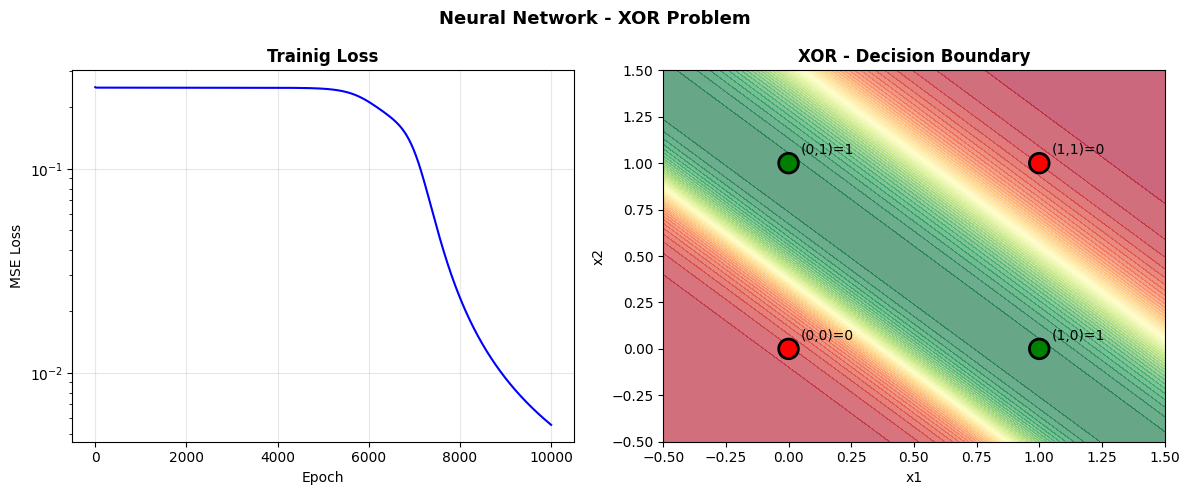

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - Loss curve
axes[0].plot(nn.losses, color="blue", linewidth=1.5)
axes[0].set_title("Trainig Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

# Chart 2 - Decision boundary
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                    np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn.forward(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, levels=50, cmap="RdYlGn", alpha=0.6)
colors = ["red" if yi == 0 else "green" for yi in y_xor]
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200,
               edgecolors="black", linewidth=2, zorder=5)

for xi, yi in zip(X_xor, y_xor):
    axes[1].annotate(f"({int(xi[0])},{int(xi[1])})={int(yi)}",
                    xy=(xi[0], xi[1]),
                    xytext=(xi[0]+0.05, xi[1]+0.05), fontsize=10)

axes[1].set_title("XOR - Decision Boundary", fontsize=12, fontweight="bold")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.suptitle("Neural Network - XOR Problem", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("neural_network_xor.png", dpi=300)
plt.show()

## 5. Key Observations

| Model | XOR Accuracy | Why |
|-------|-------------|-----|
| Perceptron | 50% | Linear boundary only |
| Neural Network | 100% | Two boundaries combined |

## Key Insight
The hidden layer learned two linear boundaries.
The output layer combined them into a non-linear decision boundary.

This is the fundamental power of deep learning:
- Each layer learns a representation
- Deeper layers combine simpler representations into complex ones

## What I Learned
Sigmoid is differentiable — this is what makes backpropagation possible.
The step function in perceptron has zero gradient — it cannot learn through layers.

Loss plateaued until epoch ~6000, then dropped sharply.
This is common — the network gets "stuck" before finding the right direction.

## Next
How does backpropagation actually compute gradients?
-> 03_backpropagation.ipynb